# Convolutional Neural Networks for Eye Disease Detection

## Authors

Laura Cahill, Olivia Jones-Martin, Roberto Mercado, Zuriel Pagan

## Dataset

We use the [Retinal Fundus Multi-disease Image Dataset (RFMiD)](https://ieee-dataport.org/open-access/retinal-fundus-multi-disease-image-dataset-rfmid?check_logged_in=1) for this project, which is available on the IEEE DataPort website. It contains 3200 fundus color images captured by three different fundus cameras. The dataset is divided into a training set of 1920 images, validation set of 640 images, and testing set of 640 images. Ground truth labels are provided through CSV files, which account for 1 healthy class and 45 disease classes.

## Prerequisites

The following Python 3.12 modules are required to execute the cells of this notebook.

In [10]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from utilities import *
import pandas as pd

The following constants assume that the "All Classes" version of the dataset was downloaded from the IEEE DataPort website and placed into the same directory as this notebook.

In [11]:
DATA_PATH = 'A. RFMiD_All_Classes_Dataset'
IMAGE_PATH = f'{DATA_PATH}/1. Original Images'
GROUND_TRUTH_PATH = f'{DATA_PATH}/2. Groundtruths'
TRAINING_SET_PATH = f'{IMAGE_PATH}/a. Training Set'
VALIDATION_SET_PATH = f'{IMAGE_PATH}/b. Validation Set'
TESTING_SET_PATH = f'{IMAGE_PATH}/c. Testing Set'

GPU access is a must for complex neural networks. Running the Inception v3 model on the CPU is ill-advised.

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda')

## Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already. However, we need to make sure that the healthy class can be properly classified. We can modify the metadata to address this.

In [13]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

#for metadata in (training_metadata, validation_metadata, testing_metadata):
#    metadata.rename(columns={'Disease_Risk' : 'Healthy'}, inplace=True)
#    metadata['Healthy'] = metadata['Healthy'].apply(lambda value: int(not value))

Now, let's configure the dataset for use by ResNet-18. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [14]:
transform = transforms.Compose([
    transforms.Resize((448, 448)), # Higher resolution for small disease features
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

training_loader = DataLoader(training_dataset, batch_size=32, num_workers=6)
validation_loader = DataLoader(validation_dataset, batch_size=32, num_workers=6)
testing_loader = DataLoader(testing_dataset, batch_size=32, num_workers=6)

## Model Setup

Here, we set up Inception v3 for use on our dataset.

In [15]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) #changed to resnet-18
model.aux_logits = False
model.fc = nn.Linear(model.fc.in_features, 29)
model = model.to(device)
display(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Then, we set up the class weights, loss function, and optimizer.

In [16]:
# 1. Combine metadata 
# (Since 'Othering' is already done in the CSVs, this just stacks them)
combined_metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)

# 2. Extract only the label columns (dropping 'ID')
# This ensures we have exactly 29 columns
label_columns = combined_metadata.drop('ID', axis=1)
frequencies = label_columns.sum().to_numpy()

# 3. Calculate pos_weight for the 29 labels
# We use (Negative Samples / Positive Samples) for each class
# Adding 1e-6 prevents division by zero for extremely rare classes
total_samples = len(combined_metadata)
weights = np.sqrt((total_samples - frequencies) / (frequencies + 1e-6))
pos_weight = torch.FloatTensor(weights).to(device)

# 4. Initialize Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, 29) 
model.to(device)

# 5. Loss and Optimizer
# Passing pos_weight here is the key to fixing the 0.00 scores
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5) # Lower LR for stability

# Display to verify the weights aren't all the same
print("Weights for the 29 labels:")
display(pos_weight)

Weights for the 29 labels:


tensor([ 0.5141,  2.0158,  4.2350,  2.2624,  3.5935,  4.2617,  5.0883,  3.0865,
        11.0488,  6.2854, 10.8406,  7.1735,  2.4882,  8.3732, 17.8606, 11.2694,
         5.1794,  5.6862, 17.0267, 11.0488, 13.6834, 11.2694,  6.6386,  7.6328,
        11.5036,  9.9499, 13.6834, 17.8606,  6.6869], device='cuda:0')

## Model Evaluation

epoch 0: starting
Training done. Onto validation.
epoch 0: F1-Score: 0.0900 | Bit-Accuracy: 0.8051
epoch 1: starting
Training done. Onto validation.
epoch 1: F1-Score: 0.1102 | Bit-Accuracy: 0.8829
epoch 2: starting
Training done. Onto validation.
epoch 2: F1-Score: 0.1211 | Bit-Accuracy: 0.9447
epoch 3: starting
Training done. Onto validation.
epoch 3: F1-Score: 0.1247 | Bit-Accuracy: 0.9555
epoch 4: starting
Training done. Onto validation.
epoch 4: F1-Score: 0.1366 | Bit-Accuracy: 0.9594
epoch 5: starting
Training done. Onto validation.
epoch 5: F1-Score: 0.1484 | Bit-Accuracy: 0.9611
epoch 6: starting
Training done. Onto validation.
epoch 6: F1-Score: 0.1546 | Bit-Accuracy: 0.9628
epoch 7: starting
Training done. Onto validation.
epoch 7: F1-Score: 0.1585 | Bit-Accuracy: 0.9634
epoch 8: starting
Training done. Onto validation.
epoch 8: F1-Score: 0.1735 | Bit-Accuracy: 0.9646
epoch 9: starting
Training done. Onto validation.
epoch 9: F1-Score: 0.1822 | Bit-Accuracy: 0.9653
epoch 10: 

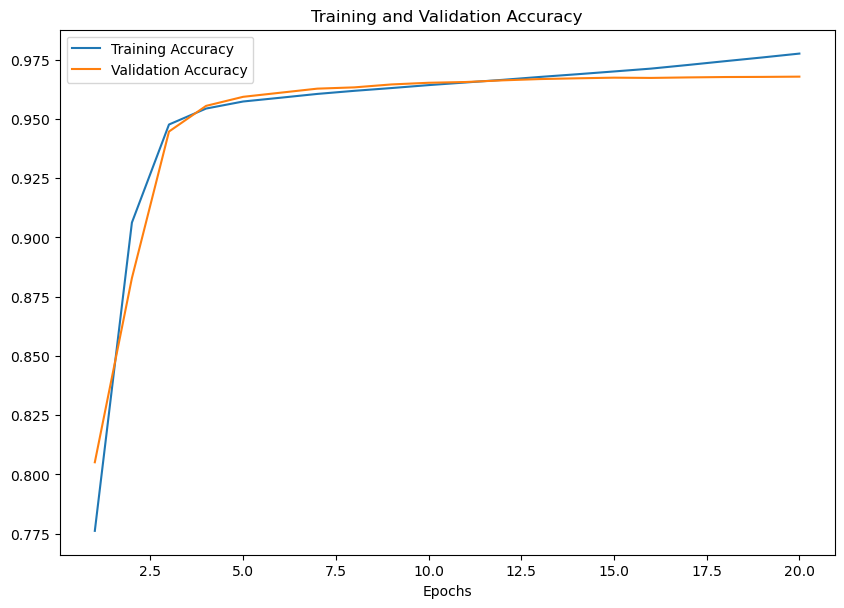

<Figure size 640x480 with 0 Axes>

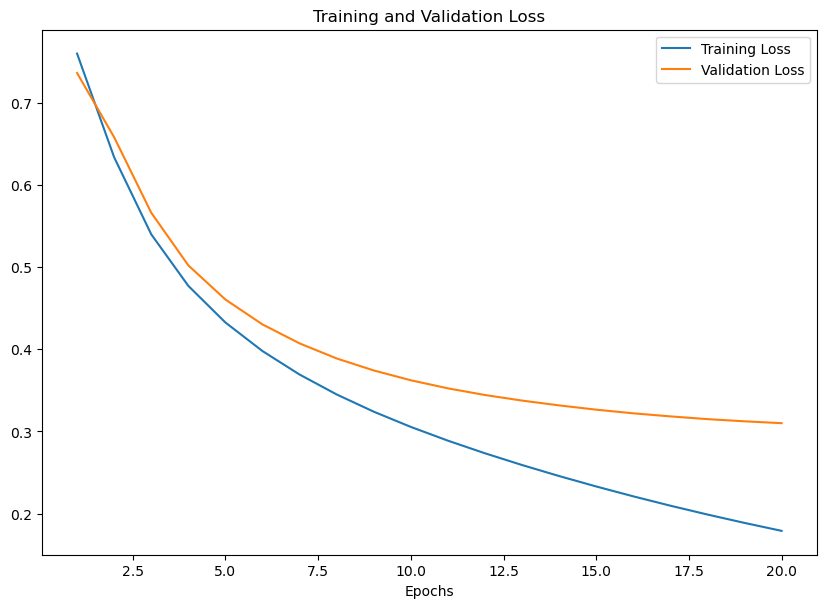

<Figure size 640x480 with 0 Axes>

In [17]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device
)


results = evaluator.train(model, 20)
results.show_accuracies()
results.show_losses()

In [19]:
# 1. Get the list of disease names (skipping the 'ID' column)
disease_names = testing_metadata.columns[1:].tolist()

# 2. Run the test method and pass those names in
evaluator.test(model, label_names=disease_names)